In [ ]:
# Cell 1 – Install libraries
!pip install -q kaggle
!pip install -q datasets evaluate jiwer accelerate librosa soundfile torchaudio
!pip install -q "transformers==4.44.0" "peft==0.10.0"
!pip install -q torchcodec


In [ ]:
# Cell 2 – Download arabic-tts from Kaggle and unzip

import os, zipfile, shutil, time
from pathlib import Path
from google.colab import files

# 1) Upload kaggle.json
print("👉 Upload your kaggle.json (from Kaggle > Account > Create New Token)")
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
for fname in uploaded:
    shutil.move(fname, "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# 2) Download dataset
DATA_ROOT = Path("/content/data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

print("⬇️ Downloading dataset from Kaggle...")
!kaggle datasets download -d mayarjao/arabic-tts -p /content/data --force

# Find the zip file (arabic-tts.zip)
zip_candidates = list(DATA_ROOT.glob("*.zip"))
if not zip_candidates:
    raise FileNotFoundError("Could not find the downloaded .zip in /content/data")

zip_path = zip_candidates[0]
print("Found zip:", zip_path)

# 3) Unzip to /content/data/arabic_tts
TARGET_DIR = DATA_ROOT / "arabic_tts"
TARGET_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(TARGET_DIR)

print("✅ Extracted to:", TARGET_DIR)
!ls -R /content/data/arabic_tts | head -n 40


👉 Upload your kaggle.json (from Kaggle > Account > Create New Token)


Saving kaggle.json to kaggle.json
⬇️ Downloading dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/mayarjao/arabic-tts
License(s): CC0-1.0
 99% 9.28G/9.33G [00:27<00:00, 591MB/s]
100% 9.33G/9.33G [00:27<00:00, 365MB/s]
Found zip: /content/data/arabic-tts.zip
✅ Extracted to: /content/data/arabic_tts
/content/data/arabic_tts:
arabic_tts

/content/data/arabic_tts/arabic_tts:
metadata.csv
metadata-wav.csv
wavs

/content/data/arabic_tts/arabic_tts/wavs:
common_voice_ar_19058307.wav
common_voice_ar_19058308.wav
common_voice_ar_19058309.wav
common_voice_ar_19058310.wav
common_voice_ar_19058311.wav
common_voice_ar_19058343.wav
common_voice_ar_19058344.wav
common_voice_ar_19058345.wav
common_voice_ar_19058346.wav
common_voice_ar_19058347.wav
common_voice_ar_19058363.wav
common_voice_ar_19058364.wav
common_voice_ar_19058365.wav
common_voice_ar_19058366.wav
common_voice_ar_19058367.wav
common_voice_ar_19058368.wav
common_voice_ar_19058375.wav
common_voice_ar_19058377.wav
common_

In [ ]:
# Cell 3 – Build manifests: arabictts_train/dev/test.csv

import pandas as pd
from pathlib import Path
import csv

DATA_DIR = Path("/content/data/arabic_tts/arabic_tts")
WAV_DIR = DATA_DIR / "wavs"

meta_path = DATA_DIR / "metadata.csv"
print("Reading:", meta_path)

# metadata.csv: text | file
df = pd.read_csv(meta_path, sep="|", header=None, names=["text", "file"])
print("Loaded rows:", len(df))
print(df.head())

# Absolute audio paths
df["audio"] = df["file"].apply(lambda x: str(WAV_DIR / x))

# Shuffle
df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

# Optional subsampling
MAX_SAMPLES = 20000
df = df.iloc[:MAX_SAMPLES]

# Split
n = len(df)
train_df = df.iloc[: int(0.8 * n)]
dev_df   = df.iloc[int(0.8 * n) : int(0.9 * n)]
test_df  = df.iloc[int(0.9 * n) :]

MANIFEST_DIR = Path("/content/manifests")
MANIFEST_DIR.mkdir(exist_ok=True)

def save_manifest(name, subset):
    out = MANIFEST_DIR / f"arabictts_{name}.csv"
    subset[["audio", "text"]].to_csv(out, index=False, quoting=csv.QUOTE_MINIMAL)
    print(f"Saved {len(subset)} → {out}")

save_manifest("train", train_df)
save_manifest("dev",   dev_df)
save_manifest("test",  test_df)


Reading: /content/data/arabic_tts/arabic_tts/metadata.csv
Loaded rows: 78720
                             text                          file
0      هو يحبّها و هي تحبّه أيضا.  common_voice_ar_24203362.wav
1    من الممكن أنها لن تأتي غداً.  common_voice_ar_22931432.wav
2                       إبنك بطل.  common_voice_ar_26338992.wav
3       جاء ذلك الغبيّ يبحث عنّي.  common_voice_ar_35782277.wav
4  سامي يعلم أنّ ليلى غاضبة عليه.  common_voice_ar_24259106.wav
Saved 16000 → /content/manifests/arabictts_train.csv
Saved 2000 → /content/manifests/arabictts_dev.csv
Saved 2000 → /content/manifests/arabictts_test.csv


In [ ]:
# Cell 4 – Load CSV manifests with datasets

from datasets import load_dataset

MANIFEST_DIR = "/content/manifests"

data_files = {
    "train": f"{MANIFEST_DIR}/arabictts_train.csv",
    "validation": f"{MANIFEST_DIR}/arabictts_dev.csv",
    "test": f"{MANIFEST_DIR}/arabictts_test.csv",
}

raw_datasets = load_dataset("csv", data_files=data_files)
raw_datasets


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['audio', 'text'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['audio', 'text'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['audio', 'text'],
        num_rows: 2000
    })
})

In [ ]:
# Cell 5 – Cast audio column & load Whisper processor

from datasets import Audio
from transformers import WhisperProcessor

# Cast "audio" column to Audio (auto-loads wavs)
raw_datasets = raw_datasets.cast_column("audio", Audio(sampling_rate=16000))

processor = WhisperProcessor.from_pretrained(
    "openai/whisper-small",
    language="arabic",
    task="transcribe",
)

# Fix padding tokens
processor.tokenizer.pad_token = processor.tokenizer.eos_token
processor.tokenizer.pad_token_id = processor.tokenizer.eos_token_id

raw_datasets["train"][0]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

{'audio': <datasets.features._torchcodec.AudioDecoder at 0x78c5dff5d9d0>,
 'text': 'سحقا، يا له من مخادع'}

In [ ]:
# Cell 6 – Precompute log-Mel input_features + labels

def prepare_batch(batch):
    # Audio → log-Mel features
    audio = batch["audio"]
    batch["input_features"] = processor.feature_extractor(
        audio["array"], sampling_rate=16000
    )["input_features"][0]

    # Text → token IDs
    labels = processor.tokenizer(
        batch["text"],
        padding=False,
        truncation=False,
    )["input_ids"]

    batch["labels"] = labels
    return batch

processed_datasets = raw_datasets.map(
    prepare_batch,
    remove_columns=["text", "audio"],
    num_proc=2,
)

processed_datasets


Map (num_proc=2):   0%|          | 0/16000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['input_features', 'labels'],
        num_rows: 2000
    })
})

In [ ]:
# Cell 7 – Collator + Base model + LoRA model

import torch
from torch.nn.utils.rnn import pad_sequence
from transformers import WhisperForConditionalGeneration
from peft import LoraConfig, get_peft_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ---- Custom collator (same idea as before) ----
class WhisperCollator:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, batch):
        # input_features: list of [80, T] -> pad along T
        feats = [torch.tensor(item["input_features"]) for item in batch]
        input_features = pad_sequence(feats, batch_first=True)

        # labels: variable length token IDs
        labels_list = [torch.tensor(item["labels"]) for item in batch]
        labels = pad_sequence(
            labels_list,
            batch_first=True,
            padding_value=self.processor.tokenizer.pad_token_id,
        )
        # mask padding as -100 for loss
        labels = labels.masked_fill(labels == self.processor.tokenizer.pad_token_id, -100)

        return {"input_features": input_features, "labels": labels}

data_collator = WhisperCollator(processor)

# ---- Base model (for comparison only) ----
base_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
base_model.config.forced_decoder_ids = None
base_model.config.suppress_tokens = []
base_model.to(device)

# ---- LoRA model (we fine-tune this) ----
lora_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
lora_model.config.forced_decoder_ids = None
lora_model.config.suppress_tokens = []

# LoRA config – target attention projections
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj"],
)

lora_model = get_peft_model(lora_model, lora_config)
lora_model.print_trainable_parameters()
lora_model.to(device)


Using device: cuda


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

trainable params: 3,538,944 || all params: 245,273,856 || trainable%: 1.442854145857274


PeftModel(
  (base_model): LoraModel(
    (model): WhisperForConditionalGeneration(
      (model): WhisperModel(
        (encoder): WhisperEncoder(
          (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
          (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
          (embed_positions): Embedding(1500, 768)
          (layers): ModuleList(
            (0-11): 12 x WhisperEncoderLayer(
              (self_attn): WhisperSdpaAttention(
                (k_proj): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=False)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=16, bias=False)
                  )
                  (lora_B): ModuleDict(
                    (default): Linear(in_features=16, out_features=768, bias=F

In [ ]:
# Cell 8 – Build PyTorch DataLoaders

from torch.utils.data import DataLoader

train_ds = processed_datasets["train"]
val_ds   = processed_datasets["validation"]

BATCH_SIZE = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator,
)

len(train_loader), len(val_loader)


(2000, 250)

In [ ]:
# Cell 9 – LoRA training loop (no Trainer)

import math
from torch.optim import AdamW
from tqdm import tqdm

EPOCHS = 3
LR = 1e-4
GRAD_ACCUM = 1

optimizer = AdamW(lora_model.parameters(), lr=LR)

global_step = 0
log_every = 50

train_losses = []
steps = []

lora_model.train()

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)

    for step, batch in enumerate(pbar):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = lora_model(
            input_features=batch["input_features"],
            labels=batch["labels"],
        )
        loss = outputs.loss
        loss = loss / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0:
            optimizer.step()
            optimizer.zero_grad()
            global_step += 1

            train_losses.append(loss.item() * GRAD_ACCUM)
            steps.append(global_step)

            if global_step % log_every == 0:
                pbar.set_postfix({"loss": f"{loss.item() * GRAD_ACCUM:.4f}"})

    print(f"Epoch {epoch} done.")

print("✅ LoRA training finished!")


Epoch 1:   0%|          | 0/2000 [00:00<?, ?it/s]Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.43.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch 1 done.


Epoch 2 done.


Epoch 3 done.
✅ LoRA training finished!


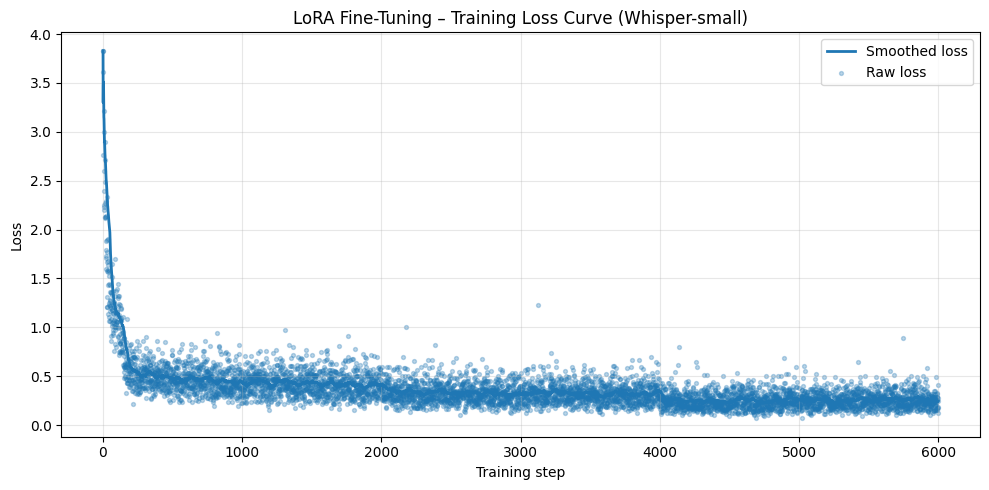

In [ ]:
# Cell 10 – Plot training loss curve (LoRA)

import matplotlib.pyplot as plt
import pandas as pd

df_loss = pd.DataFrame({"step": steps, "loss": train_losses})
df_loss["loss_smooth"] = df_loss["loss"].rolling(window=50, min_periods=1).mean()

plt.figure(figsize=(10,5))
plt.plot(df_loss["step"], df_loss["loss_smooth"], label="Smoothed loss", linewidth=2)
plt.scatter(df_loss["step"], df_loss["loss"], s=8, alpha=0.3, label="Raw loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("LoRA Fine-Tuning – Training Loss Curve (Whisper-small)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Cell 11 – Evaluate LoRA model on test set (WER/CER)

import evaluate
import numpy as np
from tqdm import tqdm

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

lora_model.eval()

test_ds = raw_datasets["test"]

pred_texts_lora = []
ref_texts = []

for example in tqdm(test_ds, desc="LoRA eval"):
    audio = example["audio"]

    inputs = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt",
    ).to(device)

    forced_ids = processor.get_decoder_prompt_ids(
        language="arabic",
        task="transcribe",
    )

    with torch.no_grad():
        gen_ids = lora_model.generate(
            inputs["input_features"],
            forced_decoder_ids=forced_ids,
            max_new_tokens=128,
            no_repeat_ngram_size=4,
            repetition_penalty=1.5,
            length_penalty=0.8,
        )

    pred = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    ref = example["text"]

    pred_texts_lora.append(pred)
    ref_texts.append(ref)

wer_lora = wer_metric.compute(predictions=pred_texts_lora, references=ref_texts)
cer_lora = cer_metric.compute(predictions=pred_texts_lora, references=ref_texts)

print(f"LoRA TEST WER: {wer_lora:.4f}")
print(f"LoRA TEST CER: {cer_lora:.4f}")


LoRA eval:   0%|          | 0/2000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:634: UserWarning: `num_beams` is set to 1. However, `length_penalty` is set to `0.8` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `length_penalty`.
  warnings.warn(
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
LoRA eval: 100%|██████████| 2000/2000 [29:27<00:00,  1.13it/s]


LoRA TEST WER: 1.3699
LoRA TEST CER: 0.8341


In [ ]:
# Cell 12 – Evaluate Base Whisper-small on same test set

base_model.eval()

pred_texts_base = []
ref_texts_base = []

for example in tqdm(test_ds, desc="Base eval"):
    audio = example["audio"]

    inputs = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"],
        return_tensors="pt",
    ).to(device)

    forced_ids = processor.get_decoder_prompt_ids(
        language="arabic",
        task="transcribe",
    )

    with torch.no_grad():
        gen_ids = base_model.generate(
            inputs["input_features"],
            forced_decoder_ids=forced_ids,
            max_new_tokens=128,
            no_repeat_ngram_size=4,
            repetition_penalty=1.5,
            length_penalty=0.8,
        )

    pred = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    ref = example["text"]

    pred_texts_base.append(pred)
    ref_texts_base.append(ref)

wer_base = wer_metric.compute(predictions=pred_texts_base, references=ref_texts_base)
cer_base = cer_metric.compute(predictions=pred_texts_base, references=ref_texts_base)

print(f"BASE TEST WER: {wer_base:.4f}")
print(f"BASE TEST CER: {cer_base:.4f}")

Base eval: 100%|██████████| 2000/2000 [09:13<00:00,  3.61it/s]

BASE TEST WER: 0.7574
BASE TEST CER: 0.3571


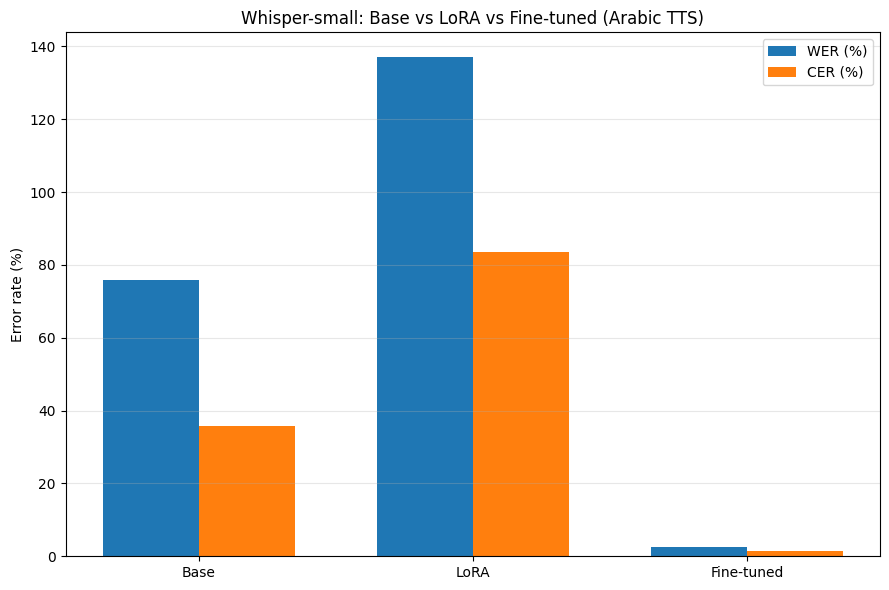

In [ ]:
# Cell 13 – Base vs LoRA vs Fine-tuned bar plot (WER & CER)

import numpy as np
import matplotlib.pyplot as plt

# Your manually provided fine-tuned metrics
wer_ft = 2.4954
cer_ft = 1.5800

models = ["Base", "LoRA", "Fine-tuned"]

wer_vals = [
    wer_base * 100,
    wer_lora * 100,
    wer_ft         # already in %
]

cer_vals = [
    cer_base * 100,
    cer_lora * 100,
    cer_ft         # already in %
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9,6))
plt.bar(x - width/2, wer_vals, width, label="WER (%)")
plt.bar(x + width/2, cer_vals, width, label="CER (%)")

plt.xticks(x, models)
plt.ylabel("Error rate (%)")
plt.title("Whisper-small: Base vs LoRA vs Fine-tuned (Arabic TTS)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
